# CMPE 180B — Physical Storage Systems Lab
## Lecture 10 In-Class Exercise (Chapter 12)
**Instructor:** Andrew Bond | **San José State University** | Spring 2026

---

### Instructions
- Work in your assigned teams (2–4 students)
- **Duration:** ~60 minutes
- Complete all 5 parts in order
- Run each code cell and fill in answers where indicated
- One team member submits the completed `.ipynb` on Canvas

| Part | Topic | Time |
|------|-------|------|
| 1 | Storage Hierarchy & Media Classification | ~8 min |
| 2 | Magnetic Disk Performance Math | ~12 min |
| 3 | SSD vs. HDD & Flash Storage Deep-Dive | ~12 min |
| 4 | Disk-Arm Scheduling Simulation | ~13 min |
| 5 | Enterprise Storage Architecture: SAN, NAS, vSAN & Ceph | ~15 min |

---
## Setup
Run the cell below first.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def check(name, got, expected, tol=0.01):
    """Simple answer checker with tolerance for floats."""
    if got is None:
        print(f"  {name}: NOT ANSWERED")
        return False
    if isinstance(expected, float):
        ok = abs(got - expected) <= tol * max(abs(expected), 1)
    else:
        ok = got == expected
    print(f"  {name}: {'CORRECT' if ok else 'INCORRECT'} — got {got}{'' if ok else f', expected {expected}'}")
    return ok

print("Setup complete. Let's go!")

Matplotlib is building the font cache; this may take a moment.


Setup complete. Let's go!


---
# Part 1 — Storage Hierarchy & Media Classification (~8 min)

The storage hierarchy (fastest/most expensive at top):

```
cache → main memory → flash memory → magnetic disk → optical disk → magnetic tape
```

Three categories:
- **Primary** (volatile): cache, main memory — fastest, loses data on power loss
- **Secondary** (non-volatile, on-line): flash/SSD, magnetic disk — moderately fast
- **Tertiary** (non-volatile, off-line/archival): optical disk, magnetic tape — cheapest per GB

### Exercise 1.1 — Classify Storage Technologies

Map each technology to `"primary"`, `"secondary"`, or `"tertiary"`.

In [2]:
# TODO: Replace each None with "primary", "secondary", or "tertiary"
answers = {
    "CPU L2 Cache":             "primary",
    "NVMe SSD":                 "secondary",
    "DDR5 DRAM":                "primary",
    "LTO Magnetic Tape":        "tertiary",
    "SATA Hard Disk Drive":     "secondary",
    "Blu-ray Optical Disc":     "tertiary",
    "Battery-backed DRAM":      "primary",
    "Intel Optane (3D-XPoint)": "secondary",
}

# --- Validation ---
correct = {
    "CPU L2 Cache":             "primary",
    "NVMe SSD":                 "secondary",
    "DDR5 DRAM":                "primary",
    "LTO Magnetic Tape":        "tertiary",
    "SATA Hard Disk Drive":     "secondary",
    "Blu-ray Optical Disc":     "tertiary",
    "Battery-backed DRAM":      "primary",
    "Intel Optane (3D-XPoint)": "secondary",
}

score = sum(1 for k in answers if check(k, answers[k], correct[k]))
print(f"\nScore: {score}/{len(correct)}")


  CPU L2 Cache: CORRECT — got primary
  NVMe SSD: CORRECT — got secondary
  DDR5 DRAM: CORRECT — got primary
  LTO Magnetic Tape: CORRECT — got tertiary
  SATA Hard Disk Drive: CORRECT — got secondary
  Blu-ray Optical Disc: CORRECT — got tertiary
  Battery-backed DRAM: CORRECT — got primary
  Intel Optane (3D-XPoint): CORRECT — got secondary

Score: 8/8


### Exercise 1.2 — Storage Trade-off Scenarios (Short Answer)

Three factors affect media choice: **speed**, **cost per unit of data**, and **reliability**.

**Q1:** A startup needs to store 500 TB of security camera footage that is rarely accessed but must be kept for 7 years for legal compliance. Which tier and medium? Why?

**Q2:** A high-frequency trading firm needs sub-microsecond access to its order book data. Which tier and medium? Why?

**Q3:** Volatile storage is faster, so why don’t databases just keep everything in DRAM?

Double-click this cell to edit.

---

**A1:** Tertiary storage, magnetic tape (e.g., LTO). The data is rarely accessed ("cold"/archival) and only needs to satisfy a 7-year compliance retention window, so access speed barely matters. Tape has by far the lowest cost per GB of any medium, which dominates the decision for 500 TB kept mostly untouched for years.

**A2:** Primary storage, DRAM (ideally on the same NUMA node as the CPU, possibly with kernel-bypass/RDMA networking). Sub-microsecond access rules out anything secondary or tertiary — even NVMe SSDs have access latencies in the tens-of-microseconds range. Only cache/DRAM can hit sub-microsecond latency, so the firm accepts DRAM's volatility and high cost per GB in exchange for speed.

**A3:** DRAM is volatile — all data is lost on power loss, a crash, or a reboot. Databases must guarantee durability (the "D" in ACID): once a transaction commits, it must survive a failure. They also typically hold far more data than fits affordably in DRAM. So databases use DRAM as a cache/buffer pool for hot data and performance, but persist the actual data (and write-ahead logs) to non-volatile secondary storage.

---


---
# Part 2 — Magnetic Disk Performance Math (~12 min)

Key formulas:

| Metric | Formula |
|--------|---------|
| **Avg. rotational latency** | (60 / RPM) × 1000 / 2 &nbsp;ms |
| **Transfer time** for *B* bytes | (*B* / transfer_rate) |
| **Access time** (random read) | seek_time + rotational_latency + transfer_time |
| **IOPS** (random 4KB) | 1000 / access_time_ms |
| **MTTF of N-disk system** | individual_MTTF / N |

### Exercise 2.1 — Single-Disk Access Time & IOPS

A 7200 RPM HDD: avg seek = **8 ms**, transfer rate = **150 MB/s**, block = **4 KB**.

In [3]:
rpm = 7200
avg_seek_ms = 8.0
transfer_rate_MBs = 150
block_KB = 4

# Step 1: Average rotational latency (ms)
avg_rot_latency_ms = (60 / rpm) * 1000 / 2

# Step 2: Transfer time for one 4 KB block (ms)
transfer_time_ms = (block_KB / 1024) / transfer_rate_MBs * 1000

# Step 3: Total access time for one random read (ms)
access_time_ms = avg_seek_ms + avg_rot_latency_ms + transfer_time_ms

# Step 4: IOPS
iops = 1000 / access_time_ms

# --- Check ---
e_rot = (60 / rpm) * 1000 / 2
e_xfer = (block_KB / 1024) / transfer_rate_MBs * 1000
e_acc = avg_seek_ms + e_rot + e_xfer
e_iops = 1000 / e_acc

check("Rotational latency (ms)", round(avg_rot_latency_ms, 3) if avg_rot_latency_ms else None, round(e_rot, 3))
check("Transfer time (ms)", round(transfer_time_ms, 4) if transfer_time_ms else None, round(e_xfer, 4))
check("Access time (ms)", round(access_time_ms, 3) if access_time_ms else None, round(e_acc, 3))
check("IOPS", round(iops, 1) if iops else None, round(e_iops, 1))

print(f"\nReference: rot={e_rot:.3f} ms, xfer={e_xfer:.4f} ms, access={e_acc:.3f} ms, IOPS={e_iops:.1f}")


  Rotational latency (ms): CORRECT — got 4.167
  Transfer time (ms): CORRECT — got 0.026
  Access time (ms): CORRECT — got 12.193
  IOPS: CORRECT — got 82.0

Reference: rot=4.167 ms, xfer=0.0260 ms, access=12.193 ms, IOPS=82.0


### Exercise 2.2 — Sequential vs. Random Access

Compare reading **1,000 contiguous 4 KB blocks** (sequential) vs. **1,000 random 4 KB blocks**.

In [4]:
N = 1000

# Sequential: 1 seek + 1 rotation + transfer ALL N blocks
seq_ms = avg_seek_ms + avg_rot_latency_ms + (N * block_KB / 1024) / transfer_rate_MBs * 1000

# Random: N * (seek + rotation + transfer per block)
rand_ms = N * access_time_ms

# --- Check ---
e_seq = avg_seek_ms + e_rot + (N * block_KB / 1024) / transfer_rate_MBs * 1000
e_rand = N * e_acc

check("Sequential (ms)", round(seq_ms, 2) if seq_ms else None, round(e_seq, 2))
check("Random (ms)", round(rand_ms, 2) if rand_ms else None, round(e_rand, 2))

print(f"\nSequential: {e_seq:.1f} ms ({e_seq/1000:.2f} s) | Random: {e_rand:.1f} ms ({e_rand/1000:.2f} s)")
print(f"Random is ~{e_rand/e_seq:.0f}x slower!")


  Sequential (ms): CORRECT — got 38.21
  Random (ms): CORRECT — got 12192.71

Sequential: 38.2 ms (0.04 s) | Random: 12192.7 ms (12.19 s)
Random is ~319x slower!


### Exercise 2.3 — MTTF & Reliability

In [5]:
num_disks = 200
mttf_individual = 800_000  # hours

# System MTTF = individual / N
system_mttf_hours = mttf_individual / num_disks
system_mttf_days = system_mttf_hours / 24

# --- Check ---
e_h = mttf_individual / num_disks
e_d = e_h / 24
check("System MTTF (hours)", system_mttf_hours, e_h)
check("System MTTF (days)", round(system_mttf_days, 1) if system_mttf_days else None, round(e_d, 1))
print(f"\nWith {num_disks} disks: expect a failure roughly every {e_d:.0f} days.")


  System MTTF (hours): CORRECT — got 4000.0
  System MTTF (days): CORRECT — got 166.7

With 200 disks: expect a failure roughly every 167 days.


---
# Part 3 — SSD vs. HDD & Flash Storage Deep-Dive (~12 min)

Key points:
- SSDs: **no seek/rotation**, much higher IOPS, faster transfer
- NAND flash: pages written once, must erase whole block first (256 KB–1 MB)
- **FTL** remaps logical→physical pages; **wear leveling** distributes writes
- Limited erase cycles: 100K–1M per block

### Exercise 3.1 — Performance Comparison Chart

Fill in typical values from lecture.

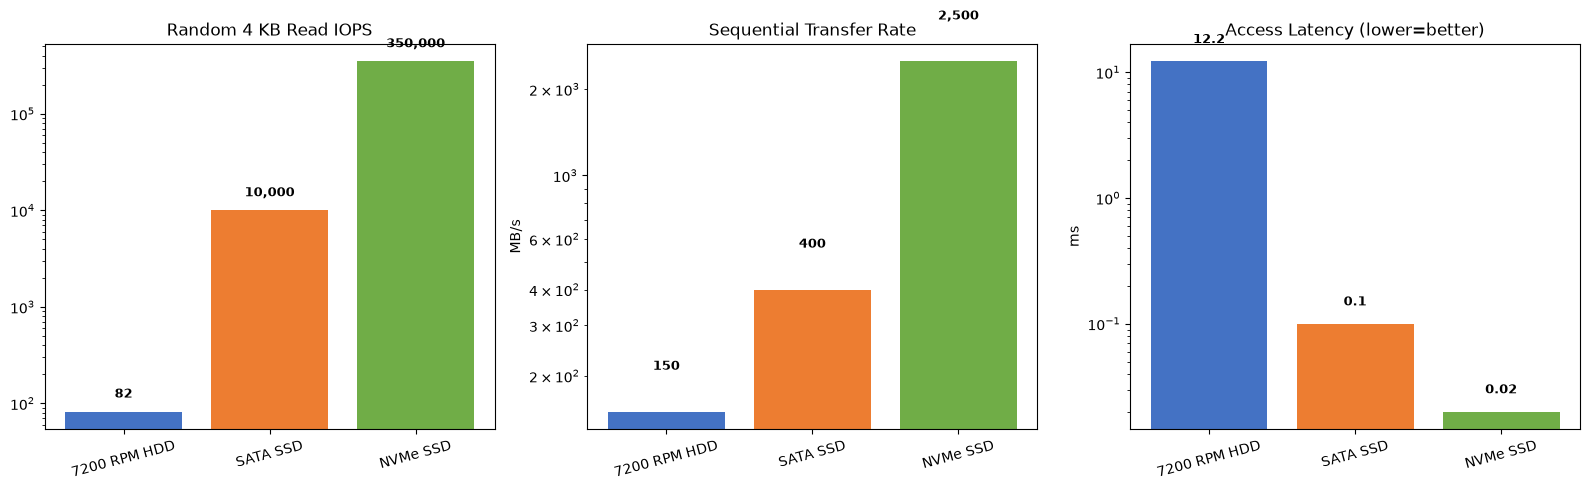

NVMe is 4268x more IOPS, 17x faster sequential, and 610x lower latency than HDD.


In [6]:
devices = {
    "7200 RPM HDD": {
        "random_4k_iops":    round(e_iops),  # ~82, from Part 2 (within 50-200 range)
        "seq_MBs":           150,            # matches our transfer_rate_MBs
        "access_latency_ms": round(e_acc, 1),# ~12.2 ms, from Part 2
    },
    "SATA SSD": {
        "random_4k_iops":    10000,   # ~10,000 single-queue
        "seq_MBs":           400,     # ~400 MB/s
        "access_latency_ms": 0.1,    # ~100 us (given)
    },
    "NVMe SSD": {
        "random_4k_iops":    350000,  # ~350,000 with QD-32
        "seq_MBs":           2500,    # 2000-3000 MB/s
        "access_latency_ms": 0.02,   # ~20 us (given)
    },
}

filled = all(v is not None for d in devices.values() for v in d.values())
if not filled:
    print("Fill in all None values above, then re-run.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    names = list(devices.keys())
    colors = ['#4472C4', '#ED7D31', '#70AD47']

    for ax, (key, title, unit) in zip(axes, [
        ("random_4k_iops", "Random 4 KB Read IOPS", ""),
        ("seq_MBs", "Sequential Transfer Rate", "MB/s"),
        ("access_latency_ms", "Access Latency (lower=better)", "ms"),
    ]):
        vals = [devices[n][key] for n in names]
        ax.bar(names, vals, color=colors)
        ax.set_title(title)
        ax.set_ylabel(unit)
        ax.set_yscale('log')
        for i, v in enumerate(vals):
            ax.text(i, v * 1.4, f"{v:,}", ha='center', fontweight='bold', fontsize=9)
        ax.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

    hdd, nvme = devices["7200 RPM HDD"], devices["NVMe SSD"]
    print(f"NVMe is {nvme['random_4k_iops']/hdd['random_4k_iops']:.0f}x more IOPS, "
          f"{nvme['seq_MBs']/hdd['seq_MBs']:.0f}x faster sequential, "
          f"and {hdd['access_latency_ms']/nvme['access_latency_ms']:.0f}x lower latency than HDD.")


### Exercise 3.2 — SSD Write Endurance

An enterprise SSD: **1 TB** capacity, **1 DWPD** (Drive Write Per Day) over a **5-year** warranty.  
A database writes **200 GB/day** of app data, but **write amplification** = **3x**.

In [7]:
capacity_tb = 1.0
dwpd = 1
warranty_years = 5
app_writes_gb_day = 200
write_amplification = 3

actual_nand_writes_gb_day = app_writes_gb_day * write_amplification
tbw_tb = capacity_tb * dwpd * 365 * warranty_years
days_to_exhaust = (tbw_tb * 1024) / actual_nand_writes_gb_day
years_to_exhaust = days_to_exhaust / 365

e_nand = app_writes_gb_day * write_amplification
e_tbw = capacity_tb * dwpd * 365 * warranty_years
e_days = (e_tbw * 1024) / e_nand
e_years = e_days / 365

check("NAND writes (GB/day)", actual_nand_writes_gb_day, float(e_nand))
check("TBW (TB)", tbw_tb, float(e_tbw))
check("Days to exhaust", round(days_to_exhaust, 1) if days_to_exhaust else None, round(e_days, 1))
check("Years to exhaust", round(years_to_exhaust, 2) if years_to_exhaust else None, round(e_years, 2))

print(f"\nThe drive wears out in ~{e_years:.1f} years — {'BEFORE' if e_years < warranty_years else 'after'} the {warranty_years}-year warranty!")
print("Write amplification significantly impacts SSD lifespan.")


  NAND writes (GB/day): CORRECT — got 600
  TBW (TB): CORRECT — got 1825.0
  Days to exhaust: CORRECT — got 3114.7
  Years to exhaust: CORRECT — got 8.53

The drive wears out in ~8.5 years — after the 5-year warranty!
Write amplification significantly impacts SSD lifespan.


### Exercise 3.3 — Flash Concepts (Short Answer)

**Q1:** Why can’t a NAND flash page be overwritten in place? What must happen first?

**Q2:** What is **wear leveling**, and why is it necessary?

**Q3:** What is the role of the **Flash Translation Layer (FTL)**?

**Q4:** SLC flash is faster and more durable than MLC/TLC. Why do most consumer SSDs use MLC or TLC?

---

**A1:** Writing a flash page can only flip bits in one direction (e.g., 1→0); to set bits back the other way, the entire containing erase block (256 KB–1 MB, spanning many pages) must first be erased. So a page can't simply be overwritten in place — the controller must erase the whole block before it can be rewritten, which is why flash SSDs do out-of-place writes (write to a fresh page elsewhere, mark the old one invalid) instead.

**A2:** Wear leveling is the strategy the SSD controller uses to spread writes/erases evenly across all physical blocks, instead of repeatedly hammering the same blocks. It's necessary because each flash block only tolerates a limited number of erase cycles (100K–1M); without wear leveling, "hot" blocks would wear out and fail long before the rest of the drive, drastically shortening the SSD's usable lifespan.

**A3:** The FTL is the layer (usually firmware in the SSD controller) that maps logical block addresses (what the OS/filesystem thinks it's writing to) to physical NAND page/block locations. It also implements wear leveling, garbage collection (reclaiming invalidated pages), and bad-block management — all transparently, so the OS sees a normal block device even though the physical layout is constantly being rewritten and rearranged underneath.

**A4:** SLC (1 bit/cell) is faster and far more durable, but it stores only 1 bit per cell, so for the same silicon area you get much less capacity — making it expensive per GB. MLC/TLC (2–3 bits/cell) trade some speed and endurance for 2–3x (or more) the storage density at a much lower cost per GB, which is what price-sensitive consumer SSDs need; most consumers don't come close to exhausting TLC's write endurance under normal use anyway.

---


---
# Part 4 — Disk-Arm Scheduling Simulation (~13 min)

**Disk-arm scheduling** reorders I/O requests to minimize seek distance:

- **FCFS:** process in arrival order
- **SSTF:** always serve the nearest pending request
- **SCAN (Elevator):** sweep one direction, then reverse

### Exercise 4.1 — Implement the Algorithms

Disk has **200 tracks** (0–199). Arm starts at **track 53**, moving toward higher tracks.

In [8]:
requests = [98, 183, 37, 122, 14, 124, 65, 67]
start = 53
max_track = 199

def total_seek(order, start_pos):
    total, pos = 0, start_pos
    for track in order:
        total += abs(track - pos)
        pos = track
    return total


def fcfs(reqs, start_pos):
    # return the request list as-is (arrival order)
    return list(reqs)


def sstf(reqs, start_pos):
    order, remaining, pos = [], list(reqs), start_pos
    while remaining:
        # find nearest request to current pos
        nearest = min(remaining, key=lambda t: abs(t - pos))
        order.append(nearest)
        remaining.remove(nearest)
        pos = nearest
    return order


def scan(reqs, start_pos):
    # split into up (>= start, ascending) and down (< start, descending)
    up = sorted(t for t in reqs if t >= start_pos)
    down = sorted((t for t in reqs if t < start_pos), reverse=True)
    return up + down if (up is not None and down is not None) else None


algorithms = {"FCFS": fcfs(requests, start), "SSTF": sstf(requests, start), "SCAN": scan(requests, start)}

print(f"Requests: {requests}")
print(f"Start: track {start}\n")
for name, order in algorithms.items():
    if order is None:
        print(f"{name}: NOT IMPLEMENTED")
    else:
        print(f"{name}: {order}  |  total seek = {total_seek(order, start)} tracks")


Requests: [98, 183, 37, 122, 14, 124, 65, 67]
Start: track 53

FCFS: [98, 183, 37, 122, 14, 124, 65, 67]  |  total seek = 640 tracks
SSTF: [65, 67, 37, 14, 98, 122, 124, 183]  |  total seek = 236 tracks
SCAN: [65, 67, 98, 122, 124, 183, 37, 14]  |  total seek = 299 tracks


### Exercise 4.2 — Visualize Arm Movement

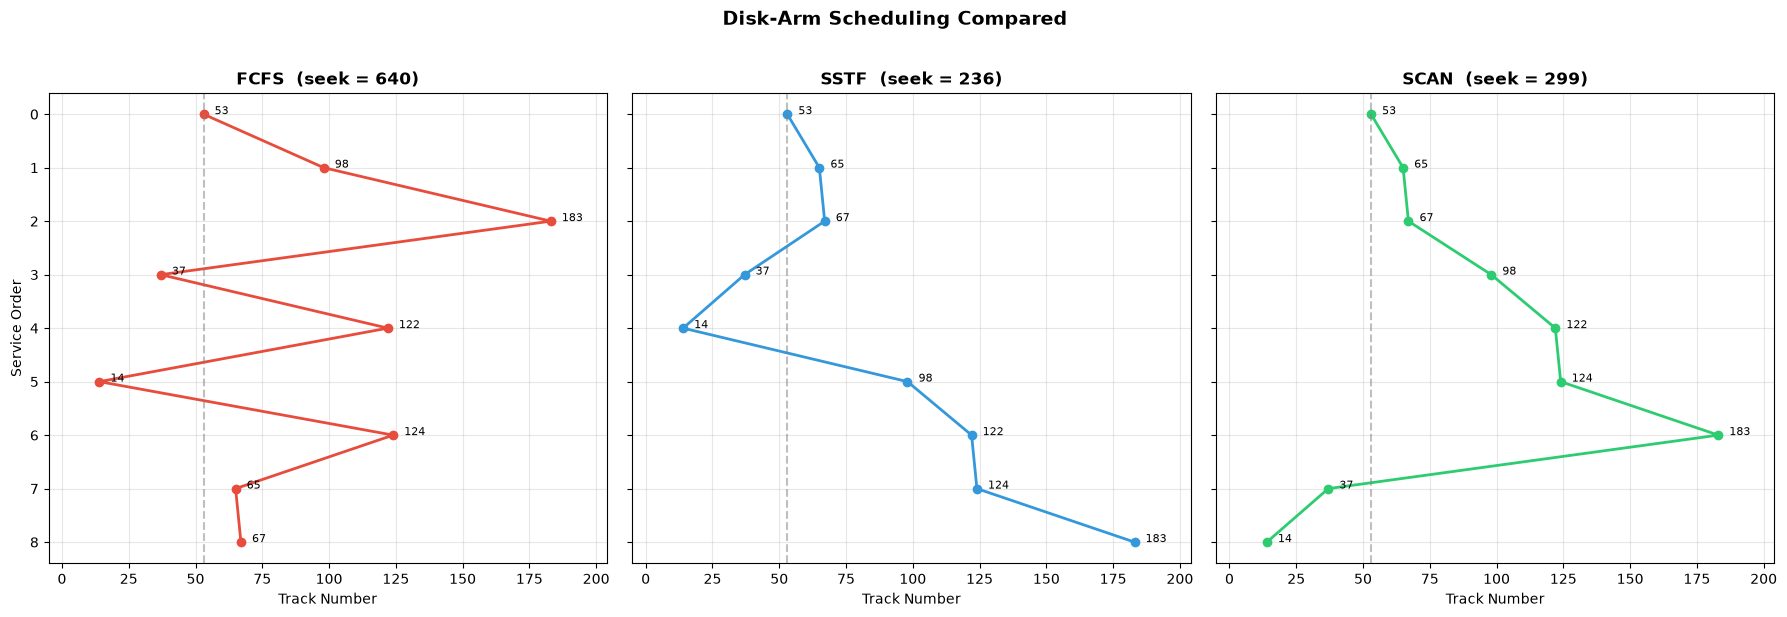

In [9]:
algo_colors = {"FCFS": "#E74C3C", "SSTF": "#3498DB", "SCAN": "#2ECC71"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, (name, order) in enumerate(algorithms.items()):
    ax = axes[idx]
    if order is None:
        ax.set_title(f"{name} — NOT IMPLEMENTED")
        continue
    path = [start] + list(order)
    ax.plot(path, range(len(path)), marker='o', color=algo_colors[name], linewidth=2, markersize=6)
    for i, t in enumerate(path):
        ax.annotate(f"{t}", (t, i), textcoords="offset points", xytext=(8, 0), fontsize=8)
    ax.set_title(f"{name}  (seek = {total_seek(order, start)})", fontweight='bold')
    ax.set_xlabel("Track Number")
    if idx == 0: ax.set_ylabel("Service Order")
    ax.set_xlim(-5, max_track + 5)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=start, color='gray', linestyle='--', alpha=0.5)

plt.suptitle("Disk-Arm Scheduling Compared", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Exercise 4.3 — Scheduling Questions

**Q1:** Which algorithm gave the shortest total seek distance? Is it always optimal?

**Q2:** SSTF can cause **starvation**. How does SCAN solve this?

**Q3:** Do disk-scheduling algorithms still matter for SSDs? Why or why not?

---

**A1:** SSTF gave the shortest total seek distance in this run (236 tracks, vs. 299 for SCAN and 640 for FCFS). SSTF is not always optimal, though — it's a greedy algorithm that picks the nearest request at each step, which can still lead to a longer total path than a globally optimal ordering (this is essentially the traveling-salesman problem), and it can starve far-away requests that keep getting skipped in favor of closer ones.

**A2:** SSTF can starve a request that sits far from the arm if a steady stream of closer requests keeps arriving — the arm never gets around to it. SCAN sweeps in one direction to the end of the disk (or to the last request) before reversing, so every pending request is guaranteed to be serviced within, at most, one full sweep — bounding the worst-case wait and preventing starvation.

**A3:** They matter much less for SSDs, and some of them (like SCAN's elevator logic) are essentially irrelevant. SSDs have no mechanical seek/rotation, so random and sequential access times are close to uniform — there's no "distance" between logical block addresses the way there is between tracks on a spinning disk. Schedulers for SSDs instead focus on different concerns: maximizing queue depth/parallelism across the device's internal channels, fairness between I/O streams, and minimizing write amplification — not minimizing arm travel.

---


---
# Part 5 — Enterprise Storage Architecture (~15 min)

The lecture covered **DAS**, **NAS**, and **SAN** as foundational storage topologies. Modern enterprises extend these with **software-defined storage** (SDS) solutions. This section connects the lecture’s concepts to real-world systems.

## Background: Traditional vs. Software-Defined Storage

### Traditional (from lecture)
| Architecture | Description | Interface | Best For |
|---|---|---|---|
| **DAS** (Direct Attached) | Disks connected directly to one server via SATA/SAS/NVMe | Block device | Single-server databases |
| **NAS** (Network Attached) | File server accessed over network using NFS/SMB protocols | File system | Shared file access, home directories |
| **SAN** (Storage Area Network) | Dedicated high-speed network (Fibre Channel/iSCSI) connecting servers to shared block storage | Block device over network | Enterprise databases, VMs |

### Modern Software-Defined Storage

| System | What It Is | Architecture |
|--------|-----------|---|
| **VMware vSAN** | Aggregates local disks from a cluster of hypervisor (ESXi) hosts into a shared datastore. Each host contributes its DAS storage to a distributed pool. | Hyper-converged: compute + storage on same nodes |
| **Ceph** | Open-source distributed storage that provides **block** (RBD), **file** (CephFS), and **object** (RADOS Gateway/S3) storage from a single cluster. Uses CRUSH algorithm for data placement. | Distributed across commodity servers |
| **MinIO** | Open-source, high-performance **object storage** server compatible with Amazon S3 API. Designed for unstructured data (images, logs, backups). | Distributed or single-node |
| **Amazon EBS** | Cloud **block storage** volumes attached to EC2 instances. Under the hood, data is replicated across multiple physical disks/servers in a data center. | Cloud-managed SAN equivalent |
| **Amazon S3** | Cloud **object storage**. Stores arbitrary data as objects in buckets. Massive durability (99.999999999%). | Cloud-managed distributed object store |

### Exercise 5.1 — Map Modern Systems to Lecture Concepts

Each modern system builds on the traditional architectures and physical storage concepts from the lecture. Fill in the mapping.

In [10]:
# For each modern system, identify:
#   1. access_type: "block", "file", "object", or "all_three"
#   2. closest_traditional: "DAS", "NAS", or "SAN"
#   3. redundancy_method: how it protects data —
#      "replication", "erasure_coding", "raid", or "replication+erasure_coding"

mapping = {
    "VMware vSAN": {
        "access_type":          "block",
        "closest_traditional":  "SAN",
        "redundancy_method":    "replication",
    },
    "Ceph": {
        "access_type":          "all_three",
        "closest_traditional":  "SAN",
        "redundancy_method":    "replication+erasure_coding",
    },
    "Amazon EBS": {
        "access_type":          "block",
        "closest_traditional":  "SAN",
        "redundancy_method":    "replication",
    },
    "Amazon S3": {
        "access_type":          "object",
        "closest_traditional":  "NAS",
        "redundancy_method":    "erasure_coding",
    },
    "MinIO": {
        "access_type":          "object",
        "closest_traditional":  "NAS",
        "redundancy_method":    "erasure_coding",
    },
}

# --- Validation ---
expected = {
    "VMware vSAN": ("block", "SAN", "replication"),
    "Ceph":        ("all_three", "SAN", "replication+erasure_coding"),
    "Amazon EBS":  ("block", "SAN", "replication"),
    "Amazon S3":   ("object", "NAS", "erasure_coding"),
    "MinIO":       ("object", "NAS", "erasure_coding"),
}

score = 0
total = 0
for system, exp in expected.items():
    m = mapping[system]
    for field, ev in zip(["access_type", "closest_traditional", "redundancy_method"], exp):
        total += 1
        if check(f"{system} / {field}", m[field], ev):
            score += 1
    print()

print(f"Score: {score}/{total}")


  VMware vSAN / access_type: CORRECT — got block
  VMware vSAN / closest_traditional: CORRECT — got SAN
  VMware vSAN / redundancy_method: CORRECT — got replication

  Ceph / access_type: CORRECT — got all_three
  Ceph / closest_traditional: CORRECT — got SAN
  Ceph / redundancy_method: CORRECT — got replication+erasure_coding

  Amazon EBS / access_type: CORRECT — got block
  Amazon EBS / closest_traditional: CORRECT — got SAN
  Amazon EBS / redundancy_method: CORRECT — got replication

  Amazon S3 / access_type: CORRECT — got object
  Amazon S3 / closest_traditional: CORRECT — got NAS
  Amazon S3 / redundancy_method: CORRECT — got erasure_coding

  MinIO / access_type: CORRECT — got object
  MinIO / closest_traditional: CORRECT — got NAS
  MinIO / redundancy_method: CORRECT — got erasure_coding

Score: 15/15


### Exercise 5.2 — Ceph Architecture Exploration

Ceph is one of the most widely-used open-source distributed storage systems. It connects directly to many concepts from the lecture. Let’s explore how.

Run the cell below to visualize a Ceph cluster and answer the questions.

In [11]:
# Simulating a small Ceph cluster
# Ceph stores data as objects in "placement groups" (PGs) across OSDs (Object Storage Daemons)
# Each OSD typically corresponds to one physical disk

num_osds = 12         # 12 disks across 3 servers
num_pgs = 64          # placement groups
replication_factor = 3  # each object stored on 3 different OSDs

osd_disk_tb = 4       # each OSD is a 4 TB disk

# Total raw capacity
raw_capacity_tb = num_osds * osd_disk_tb

# Usable capacity with replication
usable_capacity_tb = raw_capacity_tb / replication_factor

# Simulate PG -> OSD mapping (simplified CRUSH algorithm)
np.random.seed(42)
servers = {f"Server {i+1}": list(range(i*4, i*4+4)) for i in range(3)}

print("=== Ceph Cluster Layout ===")
print(f"Servers: 3 | OSDs per server: 4 | Total OSDs: {num_osds}")
print(f"Disk size: {osd_disk_tb} TB | Replication factor: {replication_factor}")
print(f"Raw capacity: {raw_capacity_tb} TB | Usable capacity: {usable_capacity_tb:.0f} TB")
print(f"Storage overhead: {(1 - usable_capacity_tb/raw_capacity_tb)*100:.0f}%")
print()

for server, osds in servers.items():
    osd_labels = [f"OSD.{o} ({osd_disk_tb}TB)" for o in osds]
    print(f"  {server}: {', '.join(osd_labels)}")

# Show how replication works for a sample object
print(f"\n=== Sample Object Placement (replication=3) ===")
print("Ceph's CRUSH algorithm ensures replicas land on DIFFERENT servers:\n")

for obj_name in ["patient_record_001", "xray_image_042", "transaction_log_007"]:
    # Simplified CRUSH: hash to PG, then pick one OSD from each server
    chosen = []
    for srv_name, osds in servers.items():
        chosen.append((srv_name, np.random.choice(osds)))
    placements = [f"{srv}:OSD.{osd}" for srv, osd in chosen[:replication_factor]]
    print(f"  {obj_name} -> {', '.join(placements)}")

print("\nIf any one server goes down, every object still has 2 healthy copies!")

=== Ceph Cluster Layout ===
Servers: 3 | OSDs per server: 4 | Total OSDs: 12
Disk size: 4 TB | Replication factor: 3
Raw capacity: 48 TB | Usable capacity: 16 TB
Storage overhead: 67%

  Server 1: OSD.0 (4TB), OSD.1 (4TB), OSD.2 (4TB), OSD.3 (4TB)
  Server 2: OSD.4 (4TB), OSD.5 (4TB), OSD.6 (4TB), OSD.7 (4TB)
  Server 3: OSD.8 (4TB), OSD.9 (4TB), OSD.10 (4TB), OSD.11 (4TB)

=== Sample Object Placement (replication=3) ===
Ceph's CRUSH algorithm ensures replicas land on DIFFERENT servers:

  patient_record_001 -> Server 1:OSD.2, Server 2:OSD.7, Server 3:OSD.8
  xray_image_042 -> Server 1:OSD.2, Server 2:OSD.6, Server 3:OSD.11
  transaction_log_007 -> Server 1:OSD.0, Server 2:OSD.4, Server 3:OSD.10

If any one server goes down, every object still has 2 healthy copies!


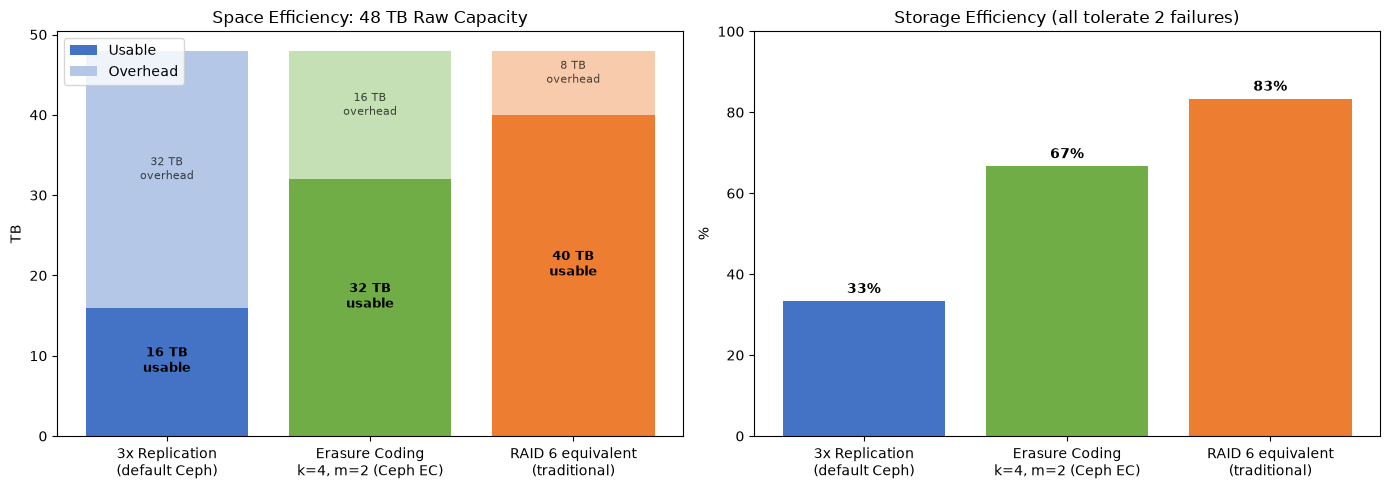

Key insight: Erasure coding gives the SAME fault tolerance as replication
but with MUCH better space efficiency — similar to how RAID 5/6 uses parity.
In fact, erasure coding is the distributed equivalent of RAID parity!


In [12]:
# Visualize: Ceph replication vs erasure coding space efficiency

configs = {
    "3x Replication\n(default Ceph)": {"raw": 48, "usable": 16, "fault_tolerance": "2 OSD failures"},
    "Erasure Coding\nk=4, m=2 (Ceph EC)": {"raw": 48, "usable": 32, "fault_tolerance": "2 OSD failures"},
    "RAID 6 equivalent\n(traditional)": {"raw": 48, "usable": 40, "fault_tolerance": "2 disk failures"},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Usable capacity
names = list(configs.keys())
usable = [configs[n]["usable"] for n in names]
overhead = [configs[n]["raw"] - configs[n]["usable"] for n in names]
colors_u = ['#4472C4', '#70AD47', '#ED7D31']
colors_o = ['#B4C7E7', '#C5E0B4', '#F8CBAD']

bars1 = axes[0].bar(names, usable, color=colors_u, label='Usable')
bars2 = axes[0].bar(names, overhead, bottom=usable, color=colors_o, label='Overhead')
axes[0].set_ylabel("TB")
axes[0].set_title("Space Efficiency: 48 TB Raw Capacity")
axes[0].legend()
for i, (u, o) in enumerate(zip(usable, overhead)):
    axes[0].text(i, u/2, f"{u} TB\nusable", ha='center', fontweight='bold', fontsize=9)
    axes[0].text(i, u + o/2, f"{o} TB\noverhead", ha='center', fontsize=8, alpha=0.7)

# Chart 2: Efficiency percentage
efficiency = [configs[n]["usable"] / configs[n]["raw"] * 100 for n in names]
axes[1].bar(names, efficiency, color=colors_u)
axes[1].set_ylabel("%")
axes[1].set_title("Storage Efficiency (all tolerate 2 failures)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(efficiency):
    axes[1].text(i, v + 2, f"{v:.0f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Key insight: Erasure coding gives the SAME fault tolerance as replication")
print("but with MUCH better space efficiency — similar to how RAID 5/6 uses parity.")
print("In fact, erasure coding is the distributed equivalent of RAID parity!")

### Exercise 5.3 — Design Challenge: Pick the Right Architecture

Your team is designing storage for an **e-commerce platform**. For each component, recommend:
1. **Storage medium** (NVMe SSD, SATA SSD, HDD, Tape)
2. **Architecture** (DAS, NAS, SAN, vSAN, Ceph, Cloud S3, etc.)
3. **Redundancy approach** (RAID level, replication factor, or erasure coding scheme)
4. **Brief justification**

| Component | Size | Access Pattern |
|-----------|------|----------------|
| **Product catalog DB** | 500 GB | Random reads, latency-critical |
| **Order transaction DB** | 2 TB | Random read/write, must not lose data |
| **Product images/video** | 20 TB | Large sequential reads, high throughput |
| **Analytics data warehouse** | 50 TB | Nightly batch scans, read-heavy |
| **Backups & audit logs** | 100 TB | Write-once, rarely read, 7-year retention |

Double-click to edit:

---

| Component | Medium | Architecture | Redundancy | Justification |
|-----------|--------|-------------|------------|---------------|
| Product catalog DB | NVMe SSD | SAN (or Amazon EBS) | RAID 10 / 3x replication | Latency-critical random reads need the lowest possible access time; NVMe gives sub-50μs latency. Block storage over a SAN/EBS lets the DB server treat it like a local fast disk while still being protected if the host fails. RAID 10 (or 3x replication) tolerates a drive failure without the parity-calculation write penalty of RAID 5/6, keeping read/write latency low. |
| Order transaction DB | NVMe SSD (with battery-backed write cache) | SAN (or Amazon EBS, Multi-AZ) | Synchronous replication (e.g. 3x, or RAID 10 + cross-AZ replica) | "Must not lose data" means durability trumps everything — synchronous replication across at least 2 (ideally 3) independent fault domains protects against both drive and whole-host/AZ failure. NVMe keeps random read/write latency low for the transactional workload; a battery-backed cache lets writes be acknowledged quickly while still being durable. |
| Product images/video | SATA SSD or HDD, served from object storage | Amazon S3 (or Ceph RGW / MinIO) | Erasure coding | Large sequential reads at high throughput are exactly what object storage over erasure coding is built for — it needs capacity and throughput, not low-latency random access, so cheaper SATA SSD/HDD-backed object storage is a good cost/performance fit. Erasure coding gives strong durability at a much lower storage overhead than 3x replication, which matters at 20 TB+ scale. |
| Analytics data warehouse | HDD (or SATA SSD if budget allows) | NAS or Ceph (CephFS) / cloud data warehouse storage | Erasure coding (or RAID 6) | Nightly batch scans are large sequential reads, not latency-sensitive — HDDs' high sequential throughput per dollar is ideal, and the read-heavy pattern tolerates erasure coding's slightly higher CPU cost to reconstruct data (rare, since reads mostly hit full data, not parity). |
| Backups & audit logs | Magnetic Tape (with a small HDD/S3 staging tier) | Tertiary / offline archive (or S3 Glacier-class storage) | Erasure coding (if staged in S3) or simple redundant tape copies | Write-once, rarely-read, 7-year retention is the textbook case for tertiary tape storage — lowest cost per GB by far, and the rare-read access pattern means tape's slow random access doesn't matter. If staged through S3/Glacier first, erasure coding keeps durability high at low overhead before migrating to tape for long-term archive. |

---


### Exercise 5.4 — Connecting It All Together (Short Answer)

**Q1:** vSAN aggregates local DAS disks into a shared pool. From the lecture’s terminology, is the resulting storage presented as a **SAN** or a **NAS** to the VMs? Why?

**Q2:** Ceph’s erasure coding (e.g., k=4, m=2) is conceptually similar to which RAID level from Tuesday’s exercise? What’s the key difference in how data is distributed?

**Q3:** The lecture mentioned that **Fibre Channel SANs** use dedicated hardware switches. How do modern solutions like **iSCSI** and **NVMe-oF** change this? What are the trade-offs?

**Q4:** A company currently uses a traditional Fibre Channel SAN with RAID 6 for their database. They’re considering migrating to Ceph. What are **two advantages** and **two risks** of this migration?

---

**A1:** It's presented as a **SAN**. Even though vSAN is built by pooling each host's local DAS disks, what it hands back to the VMs is **block-level** storage (a virtual disk/datastore), accessed over the network — not a file-system/NFS-SMB style interface. SAN vs. NAS is defined by the access interface (block vs. file), not by where the physical disks originally lived, so block-over-network = SAN-like, regardless of the underlying hyper-converged architecture.

**A2:** It's conceptually similar to **RAID 6**, since both use `k` data chunks + `m` parity/coding chunks (RAID 6 is effectively k data + 2 parity) and can tolerate up to `m` failures. The key difference is *where* the chunks live: RAID 6 stripes data+parity across disks **within a single array/enclosure**, while Ceph's erasure coding distributes the k+m chunks across **different OSDs on different physical servers** in the cluster — so Ceph can survive a whole server/rack failure, not just a single disk failure.

**A3:** Fibre Channel SANs need a dedicated FC fabric — special HBAs, FC switches, and FC cabling, separate from the regular Ethernet network. **iSCSI** carries the same SCSI block commands encapsulated over ordinary TCP/IP/Ethernet, so it reuses existing network switches/NICs instead of dedicated FC hardware. **NVMe-oF** goes further, carrying the NVMe protocol itself (not translated SCSI) over fabrics like Ethernet (RoCE), Fibre Channel, or TCP, preserving much more of NVMe's low latency/high parallelism. Trade-off: FC is expensive and requires separate dedicated hardware/expertise but gives very predictable, isolated, low-latency performance; iSCSI is cheaper and reuses commodity Ethernet but can suffer more latency/jitter from shared network traffic; NVMe-oF tries to get FC-like performance over cheaper/commodity fabrics but still needs careful network tuning (e.g., RDMA-capable NICs) to really deliver on that promise.

**A4:** Two advantages: (1) Much lower cost and more flexibility — Ceph runs on commodity servers instead of proprietary FC SAN hardware, and it scales out by adding ordinary nodes rather than forklift-upgrading a monolithic array. (2) Built-in distributed fault tolerance — Ceph can tolerate whole-server/rack failures (via CRUSH-placed replicas or erasure coding across hosts), whereas a single traditional SAN array with RAID 6 is still a single point of failure if the whole array/controller fails. Two risks: (1) Operational complexity and expertise gap — Ceph is a distributed system with many moving parts (MONs, OSDs, placement groups, CRUSH maps); misconfiguration or inadequate ops experience can cause outages or data-loss scenarios that a simpler, well-understood FC SAN wouldn't. (2) Performance/latency risk — a mature FC SAN is tuned for very low, predictable latency for demanding database workloads; Ceph (especially over Ethernet/iSCSI-like paths rather than true NVMe-oF) can introduce more latency and tail-latency variance, which could hurt a latency-sensitive production database unless the migration is carefully architected and tested.

---


---
## Submission

1. Ensure all code cells have been run and all short-answer questions are filled in
2. **File > Download > Download .ipynb**
3. Team leader submits the notebook on **Canvas**

### Grading Rubric

| Part | Points |
|------|--------|
| Part 1: Storage Hierarchy & Classification | 10 |
| Part 2: Disk Performance Calculations | 20 |
| Part 3: SSD vs HDD & Flash Deep-Dive | 20 |
| Part 4: Disk-Arm Scheduling Simulation | 20 |
| Part 5: Enterprise Storage Architecture | 30 |
| **Total** | **100** |

---
*Based on Database System Concepts, 7th Edition (Silberschatz, Korth, Sudarshan) — Chapter 12: Physical Storage Systems*